In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
!pip install pytorch-tabnet lightgbm xgboost optuna -q

True
NVIDIA RTX PRO 6000 Blackwell Server Edition
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 25.3 MB/s eta 0:00:00


In [ ]:
import time
import pandas as pd

# =========================
# RUNTIME STORAGE
# =========================

runtime_results = []

# =========================
# SAVE FUNCTION
# =========================

def save_runtime(model_name, phase, start_time, end_time):

    runtime_results.append({
        "Model": model_name,
        "Phase": phase,
        "Runtime_Seconds": round(end_time - start_time, 4)
    })

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


!pip install pytorch-tabnet

In [ ]:
df = pd.read_csv("/content/covtype.csv")

In [ ]:
# LABEL FIX
# Convert labels from 1-7 -> 0-6
# ============================================================

df["Cover_Type"] = df["Cover_Type"] - 1

In [ ]:
# FEATURE GROUPS
# ============================================================

continuous_features = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]

binary_wilderness_features = [
    col for col in df.columns
    if "Wilderness_Area" in col
]

binary_soil_features = [
    col for col in df.columns
    if "Soil_Type" in col
]

binary_features = (
    binary_wilderness_features +
    binary_soil_features
)


In [ ]:
# REMOVE HI9
# Same environment as mlprjwithval
continuous_features.remove("Hillshade_9am")


In [ ]:
# SPLIT X AND y

X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]


In [ ]:
# TRAIN / VALIDATION / TEST SPLIT
# 70 / 15 / 15


X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val_raw, X_test_raw, y_val_raw, y_test = train_test_split(
    X_temp_raw,
    y_temp_raw,
    test_size=0.50,
    stratify=y_temp_raw,
    random_state=42
)

In [ ]:
# REMOVE OUTLIERS FROM TRAIN ONLY
# Same logic as mlprjwithval

vdh_train = X_train_raw["Vertical_Distance_To_Hydrology"]

median_vdh = vdh_train.median()

outlier_score = (vdh_train - median_vdh).abs()

outlier_idx = (
    outlier_score
    .sort_values(ascending=False)
    .head(5339)
    .index
)

# Clean train only
X_train_clean = X_train_raw.drop(index=outlier_idx).copy()
y_train_clean = y_train_raw.drop(index=outlier_idx).copy()

# Keep validation and test untouched

X_val_clean = X_val_raw.copy()
X_test_clean = X_test_raw.copy()

In [ ]:
# REMOVE HI9 FEATURE

X_train_clean = X_train_clean.drop(
    columns=["Hillshade_9am"]
)

X_val_clean = X_val_clean.drop(
    columns=["Hillshade_9am"]
)

X_test_clean = X_test_clean.drop(
    columns=["Hillshade_9am"]
)


In [ ]:
X_train_df = X_train_clean.copy()
y_train = y_train_clean.copy()

X_val_df = X_val_clean.copy()

In [ ]:
# FINAL TRAIN / VALIDATION DATA

X_train_df = X_train_clean.copy()
y_train = y_train_clean.copy()

X_val_df = X_val_clean.copy()
y_val = y_val_raw.copy()

In [ ]:
from sklearn.preprocessing import StandardScaler

# SCALING

scaler = StandardScaler()

X_train_scaled = X_train_df.copy()
X_val_scaled = X_val_df.copy()
X_test_scaled = X_test_clean.copy()

# Scaling for continuous features
X_train_scaled[continuous_features] = scaler.fit_transform(
    X_train_df[continuous_features]
)

X_val_scaled[continuous_features] = scaler.transform(
    X_val_df[continuous_features]
)

X_test_scaled[continuous_features] = scaler.transform(
    X_test_clean[continuous_features]
)

In [ ]:
# KEEP FEATURE ORDER

feature_order = continuous_features + binary_features

X_train_processed = X_train_scaled[feature_order]
X_val_processed = X_val_scaled[feature_order]
X_test_processed = X_test_scaled[feature_order]


In [ ]:
# CONVERT TO NUMPY

X_train = np.array(X_train_processed, dtype=np.float32)
X_val = np.array(X_val_processed, dtype=np.float32)
X_test = np.array(X_test_processed, dtype=np.float32)

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# BALANCED SAMPLING

rus = RandomUnderSampler(
    sampling_strategy='auto',
    random_state=42
)

X_tune, y_tune = rus.fit_resample(X_train, y_train)

print(Counter(y_tune))

Counter({np.int64(0): 1915, np.int64(1): 1915, np.int64(2): 1915, np.int64(3): 1915, np.int64(4): 1915, np.int64(5): 1915, np.int64(6): 1915})


In [ ]:
import pandas as pd

print(pd.Series(y_train).value_counts().sort_index())
print("\n====================\n")
print(pd.Series(y_tune).value_counts().sort_index())

0    146654
1    195629
2     24778
3      1915
4      6608
5     12142
6     13643
Name: count, dtype: int64


0    1915
1    1915
2    1915
3    1915
4    1915
5    1915
6    1915
Name: count, dtype: int64


In [ ]:
# CHECKS

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("NaN in train:", np.isnan(X_train).sum())

print("Scaling applied successfully.")
print("HI9 removed.")
print("Outliers removed from train only.")

print(X_train.shape)
print(len(y_train))

print(X_val.shape)
print(len(y_val))

Train shape: (401369, 53)
Validation shape: (87152, 53)
Test shape: (87152, 53)
NaN in train: 0
Scaling applied successfully.
HI9 removed.
Outliers removed from train only.
(401369, 53)
401369
(87152, 53)
87152




```
 Evaluating Function for models
```



In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

def evaluate_model(name, y_true, y_pred, dataset_type=None, show_cm=False):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')

    title = name
    if dataset_type:
        title += f" - {dataset_type}"

    print(f"\n=== {title} ===")
    print(f"Accuracy : {acc:.5f}")
    print(f"F1 Score : {f1:.5f}")
    print(f"Precision: {precision:.5f}")
    print(f"Recall   : {recall:.5f}")

    if show_cm:
        print("\nConfusion Matrix:")
        print(confusion_matrix(y_true, y_pred))

    return {
        "Model": title,
        "Accuracy": acc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall
    }

#  Stacking with out  TabNet (OOF — BEFORE TUNING)

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

meta_features_no_tabnet  = np.zeros((X_train.shape[0], 14))  # 2 models × 7 classes

OOF Loop

In [ ]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

stack_no_tab_before_start = time.time()

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
    print(f"Fold {fold+1}")

    X_tr, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_tr, y_val_fold = y_train[train_idx], y_train[val_idx]

    # --- LightGBM ---
    lgb = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=64,
        random_state=42
    )
    lgb.fit(X_tr, y_tr)
    meta_features_no_tabnet [val_idx, 0:7] = lgb.predict_proba(X_val_fold)

    # --- XGBoost ---
    xgb = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42
    )
    xgb.fit(X_tr, y_tr)
    meta_features_no_tabnet [val_idx, 7:14] = xgb.predict_proba(X_val_fold)

Fold 1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000927 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1977
[LightGBM] [Info] Number of data points in the train set: 321095, number of used features: 52
[LightGBM] [Info] Start training from score -1.006806
[LightGBM] [Info] Start training from score -0.718662
[LightGBM] [Info] Start training from score -2.784945
[LightGBM] [Info] Start training from score -5.345163
[LightGBM] [Info] Start training from score -4.106486
[LightGBM] [Info] Start training from score -3.498169
[LightGBM] [Info] Start training from score -3.381691


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:38:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000872 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1976
[LightGBM] [Info] Number of data points in the train set: 321095, number of used features: 52
[LightGBM] [Info] Start training from score -1.006806
[LightGBM] [Info] Start training from score -0.718662
[LightGBM] [Info] Start training from score -2.784894
[LightGBM] [Info] Start training from score -5.345163
[LightGBM] [Info] Start training from score -4.106675
[LightGBM] [Info] Start training from score -3.498272
[LightGBM] [Info] Start training from score -3.381599


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:38:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 3
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000875 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1979
[LightGBM] [Info] Number of data points in the train set: 321095, number of used features: 52
[LightGBM] [Info] Start training from score -1.006806
[LightGBM] [Info] Start training from score -0.718662
[LightGBM] [Info] Start training from score -2.784894
[LightGBM] [Info] Start training from score -5.345163
[LightGBM] [Info] Start training from score -4.106675
[LightGBM] [Info] Start training from score -3.498272
[LightGBM] [Info] Start training from score -3.381599


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:38:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 4
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000701 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1976
[LightGBM] [Info] Number of data points in the train set: 321095, number of used features: 52
[LightGBM] [Info] Start training from score -1.006798
[LightGBM] [Info] Start training from score -0.718662
[LightGBM] [Info] Start training from score -2.784945
[LightGBM] [Info] Start training from score -5.345163
[LightGBM] [Info] Start training from score -4.106675
[LightGBM] [Info] Start training from score -3.498169
[LightGBM] [Info] Start training from score -3.381691


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:38:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000954 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1980
[LightGBM] [Info] Number of data points in the train set: 321096, number of used features: 52
[LightGBM] [Info] Start training from score -1.006809
[LightGBM] [Info] Start training from score -0.718659
[LightGBM] [Info] Start training from score -2.784948
[LightGBM] [Info] Start training from score -5.345166
[LightGBM] [Info] Start training from score -4.106489
[LightGBM] [Info] Start training from score -3.498172
[LightGBM] [Info] Start training from score -3.381694


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:38:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Meta Model

In [ ]:
from sklearn.linear_model import LogisticRegression

meta_model_no_tabnet = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

meta_model_no_tabnet.fit(meta_features_no_tabnet, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

 Retrain the models on the full training dataset




In [ ]:
lgb_final = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42
)

xgb_final = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)
lgb_final.fit(X_train, y_train)
xgb_final.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001280 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1978
[LightGBM] [Info] Number of data points in the train set: 401369, number of used features: 52
[LightGBM] [Info] Start training from score -1.006805
[LightGBM] [Info] Start training from score -0.718661
[LightGBM] [Info] Start training from score -2.784925
[LightGBM] [Info] Start training from score -5.345164
[LightGBM] [Info] Start training from score -4.106600
[LightGBM] [Info] Start training from score -3.498211
[LightGBM] [Info] Start training from score -3.381655


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:39:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

Test

In [ ]:
lgb_test = lgb_final.predict_proba(X_test)
xgb_test = xgb_final.predict_proba(X_test)

meta_test_no_tabnet = np.hstack([lgb_test, xgb_test])

final_pred_no_tabnet = meta_model_no_tabnet.predict(meta_test_no_tabnet)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Evaluation

In [ ]:
evaluate_model(
    "Stacking (No TabNet - Before Tuning)",
    y_test,
    final_pred_no_tabnet,
    show_cm=True
)


=== Stacking (No TabNet - Before Tuning) ===
Accuracy : 0.90324
F1 Score : 0.88077
Precision: 0.84718
Recall   : 0.92464

Confusion Matrix:
[[28458  2959     1     0    85     8   265]
 [ 3250 38140   183     2   658   231    32]
 [    0    63  5007    70    22   201     0]
 [    0     0    19   377     0    16     0]
 [    9    75    12     0  1321     7     0]
 [    1    28   126    26     3  2421     0]
 [   70     9     0     0     2     0  2995]]


{'Model': 'Stacking (No TabNet - Before Tuning)',
 'Accuracy': 0.9032380209289517,
 'F1': 0.8807697909282022,
 'Precision': 0.8471756398589598,
 'Recall': 0.9246354049614443}

In [ ]:
stack_no_tab_before_end = time.time()

save_runtime(
    "Stacking Without TabNet (Before Tuning)",
    "Full Pipeline",
    stack_no_tab_before_start,
    stack_no_tab_before_end
)

# Stacking with TabNet (OOF — BEFORE TUNING)

تجهيز meta_features

In [ ]:
meta_features_with_tabnet = np.zeros((X_train.shape[0], 21))  # 3 models × 7 classes

class weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

weights = dict(enumerate(class_weights))

OOF Loop

In [ ]:
stack_with_tab_before_start = time.time()


from pytorch_tabnet.tab_model import TabNetClassifier

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
    print(f"Fold {fold+1}")

    X_tr, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_tr, y_val_fold = y_train[train_idx], y_train[val_idx]

    # --- LightGBM ---
    lgb = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=64,
        random_state=42
    )
    lgb.fit(X_tr, y_tr)
    meta_features_with_tabnet[val_idx, 0:7] = lgb.predict_proba(X_val_fold)

    # --- XGBoost ---
    xgb = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42
    )
    xgb.fit(X_tr, y_tr)
    meta_features_with_tabnet[val_idx, 7:14] = xgb.predict_proba(X_val_fold)

    # --- TabNet ---
    tabnet = TabNetClassifier(
        n_d=16,
        n_a=16,
        n_steps=5,
        gamma=1.5,
        optimizer_params=dict(lr=0.02),
        seed=42,
        verbose=0,
        device_name='cuda'
    )

    tabnet.fit(
        X_tr, y_tr,
        eval_set=[(X_val_fold, y_val_fold)],
        weights=weights,
        max_epochs=50,
        patience=10
    )

    meta_features_with_tabnet[val_idx, 14:21] = tabnet.predict_proba(X_val_fold)

Fold 1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000639 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1977
[LightGBM] [Info] Number of data points in the train set: 321095, number of used features: 52
[LightGBM] [Info] Start training from score -1.006806
[LightGBM] [Info] Start training from score -0.718662
[LightGBM] [Info] Start training from score -2.784945
[LightGBM] [Info] Start training from score -5.345163
[LightGBM] [Info] Start training from score -4.106486
[LightGBM] [Info] Start training from score -3.498169
[LightGBM] [Info] Start training from score -3.381691


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:39:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Stop training because you reached max_epochs = 50 with best_epoch = 42 and best_val_0_accuracy = 0.8247


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Fold 2
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000624 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1976
[LightGBM] [Info] Number of data points in the train set: 321095, number of used features: 52
[LightGBM] [Info] Start training from score -1.006806
[LightGBM] [Info] Start training from score -0.718662
[LightGBM] [Info] Start training from score -2.784894
[LightGBM] [Info] Start training from score -5.345163
[LightGBM] [Info] Start training from score -4.106675
[LightGBM] [Info] Start training from score -3.498272
[LightGBM] [Info] Start training from score -3.381599


...

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Fold 5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000988 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1980
[LightGBM] [Info] Number of data points in the train set: 321096, number of used features: 52
[LightGBM] [Info] Start training from score -1.006809
[LightGBM] [Info] Start training from score -0.718659
[LightGBM] [Info] Start training from score -2.784948
[LightGBM] [Info] Start training from score -5.345166
[LightGBM] [Info] Start training from score -4.106489
[LightGBM] [Info] Start training from score -3.498172
[LightGBM] [Info] Start training from score -3.381694


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:03:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Stop training because you reached max_epochs = 50 with best_epoch = 47 and best_val_0_accuracy = 0.8341


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Meta Model

In [ ]:
meta_model_with_tabnet = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

meta_model_with_tabnet.fit(meta_features_with_tabnet, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

 Preparing meta-features for the stacking model

In [ ]:
lgb_final = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42
)

xgb_final = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='mlogloss',
    random_state=42
)

tabnet_final = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    optimizer_params=dict(lr=0.02),
    seed=42,
    verbose=0,
    device_name='cuda'
)

lgb_final.fit(X_train, y_train)
xgb_final.fit(X_train, y_train)

tabnet_final.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    weights=weights,
    max_epochs=50,
    patience=10
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1978
[LightGBM] [Info] Number of data points in the train set: 401369, number of used features: 52
[LightGBM] [Info] Start training from score -1.006805
[LightGBM] [Info] Start training from score -0.718661
[LightGBM] [Info] Start training from score -2.784925
[LightGBM] [Info] Start training from score -5.345164
[LightGBM] [Info] Start training from score -4.106600
[LightGBM] [Info] Start training from score -3.498211
[LightGBM] [Info] Start training from score -3.381655

Early stopping occurred at epoch 47 with best_epoch = 37 and best_val_0_accuracy = 0.83826


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


 Test

In [ ]:
lgb_test = lgb_final.predict_proba(X_test)
xgb_test = xgb_final.predict_proba(X_test)
tabnet_test = tabnet_final.predict_proba(X_test)

meta_test_with_tabnet = np.hstack([lgb_test, xgb_test, tabnet_test])

final_pred_with_tabnet= meta_model_with_tabnet.predict(meta_test_with_tabnet)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Evaluation

In [ ]:
evaluate_model("Stacking (With TabNet - Before Tuning)", y_test, final_pred_with_tabnet)


=== Stacking (With TabNet - Before Tuning) ===
Accuracy : 0.89934
F1 Score : 0.87106
Precision: 0.82896
Recall   : 0.93548


{'Model': 'Stacking (With TabNet - Before Tuning)',
 'Accuracy': 0.8993367908940701,
 'F1': 0.8710590056319223,
 'Precision': 0.8289596243411154,
 'Recall': 0.9354777822854317}

In [ ]:
stack_with_tab_before_end = time.time()

save_runtime(
    "Stacking With TabNet (Before Tuning)",
    "Full Pipeline",
    stack_with_tab_before_start,
    stack_with_tab_before_end
)

Evaluating standalone models before hyperparameter tuning




LightGBM (Before Tuning)

In [ ]:
lgb_base = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42
)
## Measuring model training time
lgb_before_start = time.time()

lgb_base.fit(X_train, y_train)

lgb_before_end = time.time()

save_runtime(
    "LightGBM (Before Tuning)",
    "Training",
    lgb_before_start,
    lgb_before_end
)



# Validation
lgb_val_pred = lgb_base.predict(X_val)
evaluate_model(
    "LGBM (Before Tuning)",
    y_val,
    lgb_val_pred,
    dataset_type="VALIDATION",
    show_cm=True
)

## Measuring model prediction time
lgb_pred_start = time.time()
# Test
lgb_test_pred = lgb_base.predict(X_test)

lgb_pred_end = time.time()

save_runtime(
    "LightGBM (Before Tuning)",
    "Prediction",
    lgb_pred_start,
    lgb_pred_end
)


evaluate_model(
    "LGBM (Before Tuning)",
    y_test,
    lgb_test_pred,
    dataset_type="TEST",
    show_cm=True
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001348 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1978
[LightGBM] [Info] Number of data points in the train set: 401369, number of used features: 52
[LightGBM] [Info] Start training from score -1.006805
[LightGBM] [Info] Start training from score -0.718661
[LightGBM] [Info] Start training from score -2.784925
[LightGBM] [Info] Start training from score -5.345164
[LightGBM] [Info] Start training from score -4.106600
[LightGBM] [Info] Start training from score -3.498211
[LightGBM] [Info] Start training from score -3.381655


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== LGBM (Before Tuning) - VALIDATION ===
Accuracy : 0.89524
F1 Score : 0.89106
Precision: 0.90966
Recall   : 0.87563

Confusion Matrix:
[[27337  4329     1     0    11     5    93]
 [ 3128 39031   149     0    73    85    29]
 [    0   123  5063    32     1   144     0]
 [    0     0    47   347     0    18     0]
 [   11   327    19     0  1058     9     0]
 [    2    90   187    16     1  2309     0]
 [  188    12     0     0     0     0  2877]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== LGBM (Before Tuning) - TEST ===
Accuracy : 0.89541
F1 Score : 0.89161
Precision: 0.90826
Recall   : 0.87722

Confusion Matrix:
[[27312  4342     1     0    10     3   108]
 [ 3119 39048   120     0   113    77    19]
 [    0   127  5068    27     7   134     0]
 [    0     0    34   349     0    29     0]
 [    8   334    18     0  1059     5     0]
 [    0    98   186    15     0  2306     0]
 [  168    12     0     0     1     0  2895]]


{'Model': 'LGBM (Before Tuning) - TEST',
 'Accuracy': 0.8954126124472187,
 'F1': 0.8916086610544844,
 'Precision': 0.908258194973536,
 'Recall': 0.8772168960594063}

XGBoost (Before Tuning)

In [ ]:
xgb_base = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)
## Measuring model training time
xgb_before_start = time.time()

xgb_base.fit(X_train, y_train)

xgb_before_end = time.time()

save_runtime(
    "XGBoost (Before Tuning)",
    "Training",
    xgb_before_start,
    xgb_before_end
)


# Validation
xgb_val_pred = xgb_base.predict(X_val)
evaluate_model(
    "XGB (Before Tuning)",
    y_val,
    xgb_val_pred,
    dataset_type="VALIDATION",
    show_cm=True
)



## Measuring model prediction time
xgb_pred_start = time.time()
# Test
xgb_test_pred = xgb_base.predict(X_test)

xgb_pred_end = time.time()

save_runtime(
    "XGBoost (Before Tuning)",
    "Prediction",
    xgb_pred_start,
    xgb_pred_end
)



evaluate_model(
    "XGB (Before Tuning)",
    y_test,
    xgb_test_pred,
    dataset_type="TEST",
    show_cm=True
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:16:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGB (Before Tuning) - VALIDATION ===
Accuracy : 0.80901
F1 Score : 0.74464
Precision: 0.82805
Recall   : 0.71000

Confusion Matrix:
[[24663  6849     2     0     9     6   247]
 [ 5370 36618   281     0    42   158    26]
 [    0   418  4630    46     0   269     0]
 [    0     0    51   348     0    13     0]
 [   17   936    30     0   436     5     0]
 [    1   381   863    16     1  1343     0]
 [  598    10     0     0     0     0  2469]]

=== XGB (Before Tuning) - TEST ===
Accuracy : 0.80931
F1 Score : 0.74526
Precision: 0.82700
Recall   : 0.70852

Confusion Matrix:
[[24751  6769     3     0     6     5   242]
 [ 5435 36547   286     1    54   147    26]
 [    0   445  4620    42     0   256     0]
 [    0     0    63   335     0    14     0]
 [   12   915    26     0   469     2     0]
 [    7   403   849    22     0  1324     0]
 [  574    15     0     0     0     0  2487]]


{'Model': 'XGB (Before Tuning) - TEST',
 'Accuracy': 0.809310170736185,
 'F1': 0.7452648928569442,
 'Precision': 0.8270002012980674,
 'Recall': 0.7085173334711615}

TabNet (Before Tuning)

In [ ]:
tabnet_base = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    optimizer_params=dict(lr=0.02),
    seed=42,
    verbose=0
)
# Measuring model training time
tabnet_before_start = time.time()

tabnet_base.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    weights=weights,
    max_epochs=50,
    patience=10
)

tabnet_before_end = time.time()

save_runtime(
    "TabNet (Before Tuning)",
    "Training",
    tabnet_before_start,
    tabnet_before_end
)



# Validation
tab_val_pred = tabnet_base.predict(X_val)
evaluate_model(
    "TabNet (Before Tuning)",
    y_val,
    tab_val_pred,
    dataset_type="VALIDATION",
    show_cm=True
)


## Measuring model prediction time
tabnet_pred_start = time.time()
# Test
tabnet_test_pred = tabnet_base.predict(X_test)

tabnet_pred_end = time.time()

save_runtime(
    "TabNet (Before Tuning)",
    "Prediction",
    tabnet_pred_start,
    tabnet_pred_end
)




evaluate_model(
    "TabNet (Before Tuning)",
    y_test,
    tabnet_test_pred,
    dataset_type="TEST",
    show_cm=True
)


Early stopping occurred at epoch 47 with best_epoch = 37 and best_val_0_accuracy = 0.83826


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



=== TabNet (Before Tuning) - VALIDATION ===
Accuracy : 0.83826
F1 Score : 0.80966
Precision: 0.74889
Recall   : 0.91434

Confusion Matrix:
[[26122  4624    21     0   199    27   783]
 [ 4621 34786   615     5  1699   573   196]
 [    0    34  4959   105    47   218     0]
 [    0     0    11   397     0     4     0]
 [    3    17     5     0  1389    10     0]
 [    0    19   167    27    13  2379     0]
 [   45     7     0     0     1     0  3024]]

=== TabNet (Before Tuning) - TEST ===
Accuracy : 0.83800
F1 Score : 0.80981
Precision: 0.75016
Recall   : 0.91393

Confusion Matrix:
[[26151  4554    22     0   208    30   811]
 [ 4675 34726   587     3  1781   551   173]
 [    0    39  4972   101    45   206     0]
 [    0     0     8   396     0     8     0]
 [    0    23    12     0  1383     6     0]
 [    0    14   163    26     7  2395     0]
 [   57     7     0     0     2     0  3010]]


{'Model': 'TabNet (Before Tuning) - TEST',
 'Accuracy': 0.8379956856985497,
 'F1': 0.8098126928612712,
 'Precision': 0.7501578736780924,
 'Recall': 0.9139334553661055}

Starting the hyperparameter tuning process

In [ ]:
# ============================================================
# ============================================================
# MANUAL TUNED MODELS
# Reusing the best configurations obtained from previous
# tuning experiments performed on a balanced subset of the
# dataset due to the large dataset size, high computational
# cost, limited session runtime, and repeated Colab crashes
# during full tuning experiments.
# ============================================================
# ============================================================
!pip install pytorch-tabnet
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

# =========================
# LightGBM Tuned
# =========================

lgb_tuned = LGBMClassifier(
    n_estimators=250,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42
)

lgb_tuned.fit(X_train, y_train)

# =========================
# XGBoost Tuned
# =========================

xgb_tuned = XGBClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='mlogloss',
    random_state=42
)

xgb_tuned.fit(X_train, y_train)

# =========================
# TabNet Tuned
# =========================

best_tabnet = TabNetClassifier(
    n_d=24,
    n_a=24,
    n_steps=5,
    gamma=1.5,
    optimizer_params=dict(lr=0.01),
    seed=42,
    verbose=0,
    device_name='cuda'
)

best_tabnet.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    weights=weights,
    max_epochs=40,
    patience=10
)

print("Manual tuned models are ready.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001020 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1978
[LightGBM] [Info] Number of data points in the train set: 401369, number of used features: 52
[LightGBM] [Info] Start training from score -1.006805
[LightGBM] [Info] Start training from score -0.718661
[LightGBM] [Info] Start training from score -2.784925
[LightGBM] [Info] Start training from score -5.345164
[LightGBM] [Info] Start training from score -4.106600
[LightGBM] [Info] Start training from score -3.498211
[LightGBM] [Info] Start training from score -3.381655
Stop training because you reached max_epochs = 40 with best_epoch = 38 and best_val_0_accuracy = 0.85345


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Manual tuned models are ready.


Evaluating LightGBM after hyperparameter tuning

In [ ]:
lgb_pred_tuned = lgb_tuned.predict(X_test)

evaluate_model(
    "LGBM (Tuned)",
    y_test,
    lgb_pred_tuned
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== LGBM (Tuned) ===
Accuracy : 0.90507
F1 Score : 0.90119
Precision: 0.91588
Recall   : 0.88822


{'Model': 'LGBM (Tuned)',
 'Accuracy': 0.905073893886543,
 'F1': 0.9011877272791445,
 'Precision': 0.9158839101591404,
 'Recall': 0.888217716334035}

 Evaluating XGBoost after hyperparameter tuning

In [ ]:
xgb_pred_tuned = xgb_tuned.predict(X_test)

evaluate_model(
    "XGB (Tuned)",
    y_test,
    xgb_pred_tuned
)


=== XGB (Tuned) ===
Accuracy : 0.81816
F1 Score : 0.76337
Precision: 0.83605
Recall   : 0.72897


{'Model': 'XGB (Tuned)',
 'Accuracy': 0.8181567835505783,
 'F1': 0.7633736335790496,
 'Precision': 0.8360466275646061,
 'Recall': 0.7289720846310879}

Evaluating TabNat after hyperparameter tuning
   

In [ ]:


pred2 = best_tabnet.predict(X_test)

evaluate_model(
    "TabNet Tuned",
    y_test,
    pred2
)




=== TabNet Tuned ===
Accuracy : 0.85339
F1 Score : 0.81281
Precision: 0.75410
Recall   : 0.91806


{'Model': 'TabNet Tuned',
 'Accuracy': 0.853394070130347,
 'F1': 0.8128101421658781,
 'Precision': 0.7540998493086765,
 'Recall': 0.9180628287450557}

# Stacking AFTER tuning (without TabNet)

OOF

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stack_no_tab_after_start = time.time()

meta_features_tuned_no_tabnet = np.zeros((X_train.shape[0], 14))  # 2 models × 7 classes

OOF Loop

In [ ]:
from sklearn.base import clone

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
    print(f"Fold {fold+1}")

    X_tr, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_tr, y_val_fold = y_train[train_idx], y_train[val_idx]

    # 🔹 لازم clone عشان ما يعيد استخدام نفس المودل
    lgb = clone(lgb_tuned)
    xgb = clone(xgb_tuned)

    # --- LightGBM ---
    lgb.fit(X_tr, y_tr)
    meta_features_tuned_no_tabnet[val_idx, 0:7] = lgb.predict_proba(X_val_fold)

    # --- XGBoost ---
    xgb.fit(X_tr, y_tr)
    meta_features_tuned_no_tabnet[val_idx, 7:14] = xgb.predict_proba(X_val_fold)

Fold 1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1977
[LightGBM] [Info] Number of data points in the train set: 321095, number of used features: 52
[LightGBM] [Info] Start training from score -1.006806
[LightGBM] [Info] Start training from score -0.718662
[LightGBM] [Info] Start training from score -2.784945
[LightGBM] [Info] Start training from score -5.345163
[LightGBM] [Info] Start training from score -4.106486
[LightGBM] [Info] Start training from score -3.498169
[LightGBM] [Info] Start training from score -3.381691


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000801 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1976
[LightGBM] [Info] Number of data points in the train set: 321095, number of used features: 52
[LightGBM] [Info] Start training from score -1.006806
[LightGBM] [Info] Start training from score -0.718662
[LightGBM] [Info] Start training from score -2.784894
[LightGBM] [Info] Start training from score -5.345163
[LightGBM] [Info] Start training from score -4.106675
[LightGBM] [Info] Start training from score -3.498272
[LightGBM] [Info] Start training from score -3.381599


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 3
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000827 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1979
[LightGBM] [Info] Number of data points in the train set: 321095, number of used features: 52
[LightGBM] [Info] Start training from score -1.006806
[LightGBM] [Info] Start training from score -0.718662
[LightGBM] [Info] Start training from score -2.784894
[LightGBM] [Info] Start training from score -5.345163
[LightGBM] [Info] Start training from score -4.106675
[LightGBM] [Info] Start training from score -3.498272
[LightGBM] [Info] Start training from score -3.381599


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000816 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1976
[LightGBM] [Info] Number of data points in the train set: 321095, number of used features: 52
[LightGBM] [Info] Start training from score -1.006798
[LightGBM] [Info] Start training from score -0.718662
[LightGBM] [Info] Start training from score -2.784945
[LightGBM] [Info] Start training from score -5.345163
[LightGBM] [Info] Start training from score -4.106675
[LightGBM] [Info] Start training from score -3.498169
[LightGBM] [Info] Start training from score -3.381691


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000892 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1980
[LightGBM] [Info] Number of data points in the train set: 321096, number of used features: 52
[LightGBM] [Info] Start training from score -1.006809
[LightGBM] [Info] Start training from score -0.718659
[LightGBM] [Info] Start training from score -2.784948
[LightGBM] [Info] Start training from score -5.345166
[LightGBM] [Info] Start training from score -4.106489
[LightGBM] [Info] Start training from score -3.498172
[LightGBM] [Info] Start training from score -3.381694


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Meta Model

In [ ]:
from sklearn.linear_model import LogisticRegression

meta_model_tuned_no_tabnet = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

meta_model_tuned_no_tabnet.fit(meta_features_tuned_no_tabnet, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

Retraining the models on the full training dataset

In [ ]:
lgb_final_tuned = clone(lgb_tuned)
xgb_final_tuned = clone(xgb_tuned)

lgb_final_tuned.fit(X_train, y_train)
xgb_final_tuned.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001088 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1978
[LightGBM] [Info] Number of data points in the train set: 401369, number of used features: 52
[LightGBM] [Info] Start training from score -1.006805
[LightGBM] [Info] Start training from score -0.718661
[LightGBM] [Info] Start training from score -2.784925
[LightGBM] [Info] Start training from score -5.345164
[LightGBM] [Info] Start training from score -4.106600
[LightGBM] [Info] Start training from score -3.498211
[LightGBM] [Info] Start training from score -3.381655


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=None,
              num_parallel_tree=None, ...)

Test

In [ ]:
lgb_test = lgb_final_tuned.predict_proba(X_test)
xgb_test = xgb_final_tuned.predict_proba(X_test)

meta_test_tuned_no_tabnet = np.hstack([lgb_test, xgb_test])

final_pred_tuned_no_tabnet = meta_model_tuned_no_tabnet.predict(meta_test_tuned_no_tabnet)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Evaluation

In [ ]:
evaluate_model(
    "Stacking (Tuned - No TabNet)",
    y_test,
    final_pred_tuned_no_tabnet
)


=== Stacking (Tuned - No TabNet) ===
Accuracy : 0.91226
F1 Score : 0.88884
Precision: 0.85644
Recall   : 0.93093


{'Model': 'Stacking (Tuned - No TabNet)',
 'Accuracy': 0.9122567468331192,
 'F1': 0.8888387058218244,
 'Precision': 0.8564370222814499,
 'Recall': 0.9309326296243438}

In [ ]:
stack_no_tab_after_end = time.time()

save_runtime(
    "Stacking Without TabNet (After Tuning)",
    "Full Pipeline",
    stack_no_tab_after_start,
    stack_no_tab_after_end
)

# Stacking AFTER tuning (with TabNet)

In [ ]:
stack_with_tab_after_start = time.time()

 meta_features

In [ ]:
meta_features_tuned_with_tabnet = np.zeros((X_train.shape[0], 21))

 OOF Loop

In [ ]:
from sklearn.base import clone

from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
    print(f"Fold {fold+1}")

    X_tr, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_tr, y_val_fold = y_train[train_idx], y_train[val_idx]

    lgb = clone(lgb_tuned)
    xgb = clone(xgb_tuned)
    tabnet = clone(best_tabnet)

    # LGB
    lgb.fit(X_tr, y_tr)
    meta_features_tuned_with_tabnet[val_idx, 0:7] = lgb.predict_proba(X_val_fold)

    # XGB
    xgb.fit(X_tr, y_tr)
    meta_features_tuned_with_tabnet[val_idx, 7:14] = xgb.predict_proba(X_val_fold)

    # TabNet
    tabnet.fit(
        X_tr, y_tr,
        eval_set=[(X_val_fold, y_val_fold)],
        weights=weights,
        max_epochs=30,
        patience=5
    )
    meta_features_tuned_with_tabnet[val_idx, 14:21] = tabnet.predict_proba(X_val_fold)

Fold 1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000760 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1977
[LightGBM] [Info] Number of data points in the train set: 267579, number of used features: 52
[LightGBM] [Info] Start training from score -1.006807
[LightGBM] [Info] Start training from score -0.718663
[LightGBM] [Info] Start training from score -2.784904
[LightGBM] [Info] Start training from score -5.344901
[LightGBM] [Info] Start training from score -4.106675
[LightGBM] [Info] Start training from score -3.498292
[LightGBM] [Info] Start training from score -3.381580


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Stop training because you reached max_epochs = 30 with best_epoch = 28 and best_val_0_accuracy = 0.72115


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Fold 2
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1977
[LightGBM] [Info] Number of data points in the train set: 267579, number of used features: 52
[LightGBM] [Info] Start training from score -1.006797
[LightGBM] [Info] Start training from score -0.718663
[LightGBM] [Info] Start training from score -2.784964
[LightGBM] [Info] Start training from score -5.344901
[LightGBM] [Info] Start training from score -4.106675
[LightGBM] [Info] Start training from score -3.498168
[LightGBM] [Info] Start training from score -3.381690


...

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Fold 3
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000631 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1980
[LightGBM] [Info] Number of data points in the train set: 267580, number of used features: 52
[LightGBM] [Info] Start training from score -1.006811
[LightGBM] [Info] Start training from score -0.718659
[LightGBM] [Info] Start training from score -2.784907
[LightGBM] [Info] Start training from score -5.345688
[LightGBM] [Info] Start training from score -4.106451
[LightGBM] [Info] Start training from score -3.498172
[LightGBM] [Info] Start training from score -3.381694


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Stop training because you reached max_epochs = 30 with best_epoch = 28 and best_val_0_accuracy = 0.8312


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


 Meta Model

In [ ]:
from sklearn.linear_model import LogisticRegression
meta_model_tuned_with_tabnet = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

meta_model_tuned_with_tabnet.fit(meta_features_tuned_with_tabnet, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

Final Training

In [ ]:
lgb_final_tuned = clone(lgb_tuned)
xgb_final_tuned = clone(xgb_tuned)
tabnet_final_tuned = clone(best_tabnet)

lgb_final_tuned.fit(X_train, y_train)
xgb_final_tuned.fit(X_train, y_train)

tabnet_final_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    weights=weights,
    max_epochs=30,
    patience=5
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001269 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1978
[LightGBM] [Info] Number of data points in the train set: 401369, number of used features: 52
[LightGBM] [Info] Start training from score -1.006805
[LightGBM] [Info] Start training from score -0.718661
[LightGBM] [Info] Start training from score -2.784925
[LightGBM] [Info] Start training from score -5.345164
[LightGBM] [Info] Start training from score -4.106600
[LightGBM] [Info] Start training from score -3.498211
[LightGBM] [Info] Start training from score -3.381655
Stop training because you reached max_epochs = 30 with best_epoch = 29 and best_val_0_accuracy = 0.83147


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Test

In [ ]:
# =========================
# INFERENCE TIME
# Stacking Tuned With TabNet
# =========================

import time
import numpy as np

start_time = time.time()

# Base model predictions
lgb_test = lgb_final_tuned.predict_proba(X_test)
xgb_test = xgb_final_tuned.predict_proba(X_test)
tabnet_test = tabnet_final_tuned.predict_proba(X_test)

# Meta features
meta_test = np.hstack([
    lgb_test,
    xgb_test,
    tabnet_test
])

# Final prediction
final_pred = meta_model_tuned_with_tabnet.predict(meta_test)

end_time = time.time()

inference_time = end_time - start_time

print(f"Inference Time: {inference_time:.4f} seconds")
print(f"Average per sample: {inference_time / len(X_test):.8f} seconds")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Inference Time: 1.1398 seconds
Average per sample: 0.00001308 seconds


Evaluation

In [ ]:
evaluate_model(
    "Stacking (Tuned - With TabNet)",
    y_test,
    final_pred_tuned_with_tabnet
)


=== Stacking (Tuned - With TabNet) ===
Accuracy : 0.90660
F1 Score : 0.87154
Precision: 0.82693
Recall   : 0.93901


{'Model': 'Stacking (Tuned - With TabNet)',
 'Accuracy': 0.9065999632825409,
 'F1': 0.8715409514384108,
 'Precision': 0.8269307070548234,
 'Recall': 0.9390112602312728}

In [ ]:
stack_with_tab_after_end = time.time()

save_runtime(
    "Stacking With TabNet (After Tuning)",
    "Full Pipeline",
    stack_with_tab_after_start,
    stack_with_tab_after_end
)

# (Visualization + Analysis)

In [ ]:
results = []

tabnet_pred_best = best_tabnet.predict(X_test)

# BEFORE TUNING
results.append(evaluate_model("LGBM Before", y_test, lgb_test_pred))
results.append(evaluate_model("XGB Before", y_test, xgb_test_pred))
results.append(evaluate_model("TabNet Before", y_test, tabnet_test_pred))
results.append(evaluate_model("Stack No Tab Before", y_test, final_pred_no_tabnet))
results.append(evaluate_model("Stack With Tab Before", y_test, final_pred_with_tabnet))

# AFTER TUNING
results.append(evaluate_model("LGBM Tuned", y_test, lgb_pred_tuned))
results.append(evaluate_model("XGB Tuned", y_test, xgb_pred_tuned))
results.append(evaluate_model("TabNet Tuned", y_test, tabnet_pred_best))
results.append(evaluate_model("Stack No Tab Tuned", y_test, final_pred_tuned_no_tabnet))
results.append(evaluate_model("Stack With Tab Tuned", y_test, final_pred_tuned_with_tabnet))


=== LGBM Before ===
Accuracy : 0.89541
F1 Score : 0.89161
Precision: 0.90826
Recall   : 0.87722

=== XGB Before ===
Accuracy : 0.80931
F1 Score : 0.74526
Precision: 0.82700
Recall   : 0.70852

=== TabNet Before ===
Accuracy : 0.83800
F1 Score : 0.80981
Precision: 0.75016
Recall   : 0.91393

=== Stack No Tab Before ===
Accuracy : 0.90324
F1 Score : 0.88077
Precision: 0.84718
Recall   : 0.92464

=== Stack With Tab Before ===
Accuracy : 0.89934
F1 Score : 0.87106
Precision: 0.82896
Recall   : 0.93548

=== LGBM Tuned ===
Accuracy : 0.90507
F1 Score : 0.90119
Precision: 0.91588
Recall   : 0.88822

=== XGB Tuned ===
Accuracy : 0.81816
F1 Score : 0.76337
Precision: 0.83605
Recall   : 0.72897

=== TabNet Tuned ===
Accuracy : 0.85339
F1 Score : 0.81281
Precision: 0.75410
Recall   : 0.91806

=== Stack No Tab Tuned ===
Accuracy : 0.91226
F1 Score : 0.88884
Precision: 0.85644
Recall   : 0.93093

=== Stack With Tab Tuned ===
Accuracy : 0.90660
F1 Score : 0.87154
Precision: 0.82693
Recall   : 0.939

In [ ]:
df_results = pd.DataFrame(results)

df_sorted = df_results.sort_values("Accuracy", ascending=False)

df_sorted.style \
    .background_gradient(cmap='YlGnBu') \
    .highlight_max(axis=0) \
    .set_caption("Model Performance Comparison")

,Model,Accuracy,F1,Precision,Recall
8,Stack No Tab Tuned,0.912257,0.888839,0.856437,0.930933
9,Stack With Tab Tuned,0.906600,0.871541,0.826931,0.939011
5,LGBM Tuned,0.905074,0.901188,0.915884,0.888218
3,Stack No Tab Before,0.903238,0.880770,0.847176,0.924635
4,Stack With Tab Before,0.899337,0.871059,0.828960,0.935478
0,LGBM Before,0.895413,0.891609,0.908258,0.877217
7,TabNet Tuned,0.853394,0.812810,0.754100,0.918063
2,TabNet Before,0.837996,0.809813,0.750158,0.913933
6,XGB Tuned,0.818157,0.763374,0.836047,0.728972
1,XGB Before,0.809310,0.745265,0.827000,0.708517


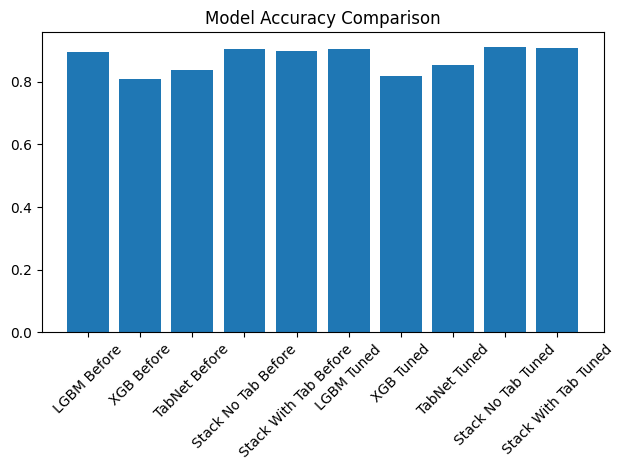

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_results["Model"], df_results["Accuracy"])
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

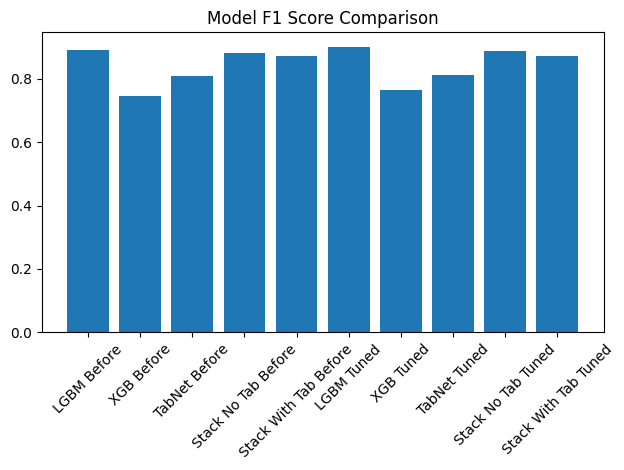

In [ ]:
plt.figure()
plt.bar(df_results["Model"], df_results["F1"])
plt.xticks(rotation=45)
plt.title("Model F1 Score Comparison")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df_results = pd.DataFrame(results)
df_results.set_index("Model", inplace=True)
df_results

,Accuracy,F1,Precision,Recall
Model,,,,
LGBM Before,0.895413,0.891609,0.908258,0.877217
XGB Before,0.809310,0.745265,0.827000,0.708517
TabNet Before,0.837996,0.809813,0.750158,0.913933
Stack No Tab Before,0.903238,0.880770,0.847176,0.924635
Stack With Tab Before,0.899337,0.871059,0.828960,0.935478
LGBM Tuned,0.905074,0.901188,0.915884,0.888218
XGB Tuned,0.818157,0.763374,0.836047,0.728972
TabNet Tuned,0.853394,0.812810,0.754100,0.918063
Stack No Tab Tuned,0.912257,0.888839,0.856437,0.930933


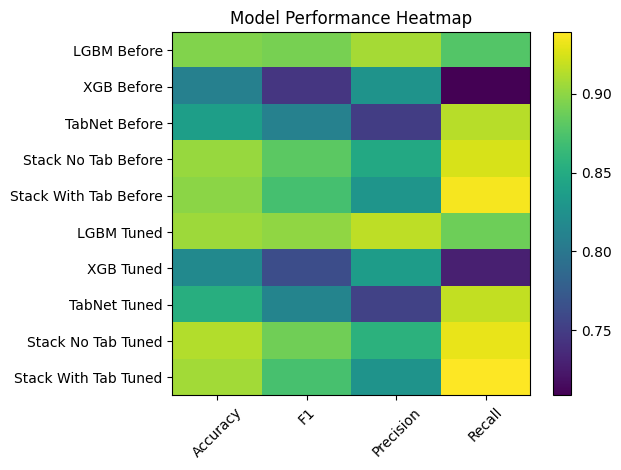

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(df_results, aspect='auto')
plt.colorbar()

plt.xticks(range(len(df_results.columns)), df_results.columns, rotation=45)
plt.yticks(range(len(df_results.index)), df_results.index)

plt.title("Model Performance Heatmap")
plt.tight_layout()
plt.show()

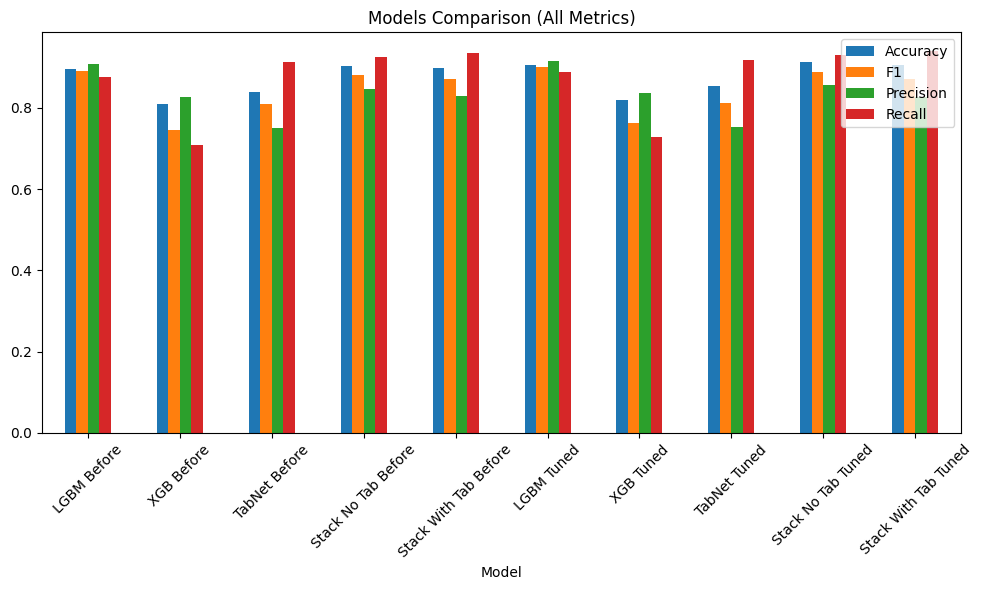

In [ ]:
df_results.plot(kind='bar', figsize=(10,6))
plt.title("Models Comparison (All Metrics)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_980/3555091107.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (df_results["Precision"][i], df_results["Recall"][i]))


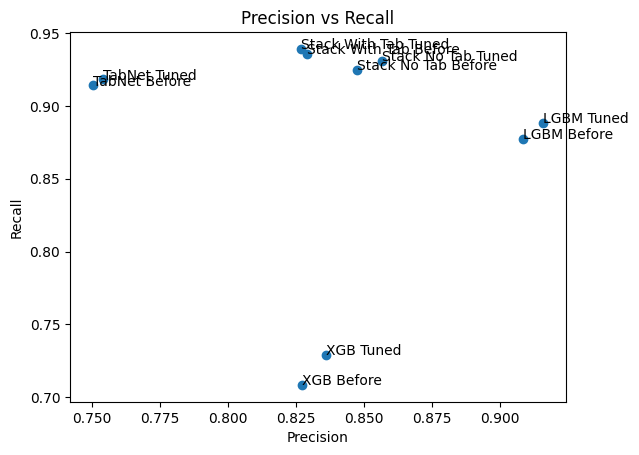

In [ ]:
plt.figure()

plt.scatter(df_results["Precision"], df_results["Recall"])

for i, txt in enumerate(df_results.index):
    plt.annotate(txt, (df_results["Precision"][i], df_results["Recall"][i]))

plt.xlabel("Precision")
plt.ylabel("Recall")
plt.title("Precision vs Recall")
plt.show()

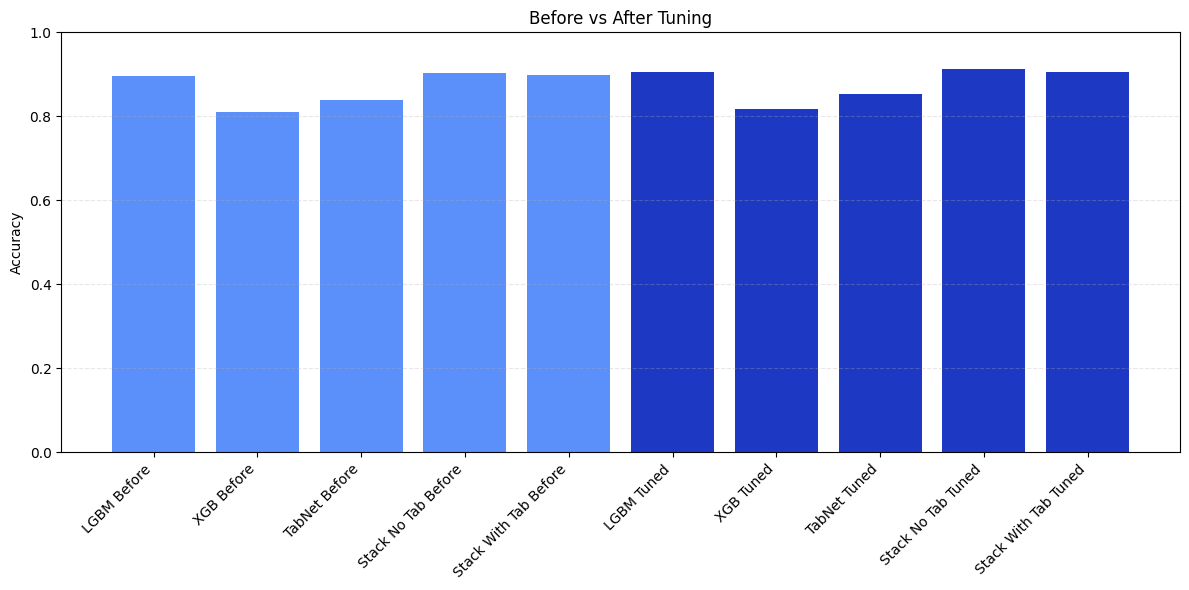

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# AUTOMATIC EXTRACTION
# =========================

model_names = []
accuracies = []
colors = []

for r in results:

    model_names.append(r['Model'])
    accuracies.append(r['Accuracy'])

    if "Before" in r['Model']:
        colors.append('#5B8FF9')   # light blue
    else:
        colors.append('#1D39C4')   # dark blue

# =========================
# PLOT
# =========================

plt.figure(figsize=(12,6))

x = np.arange(len(model_names))

plt.bar(x, accuracies, color=colors)

plt.xticks(
    x,
    model_names,
    rotation=45,
    ha='right'
)

plt.ylabel("Accuracy")
plt.title("Before vs After Tuning")
plt.ylim(0, 1)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

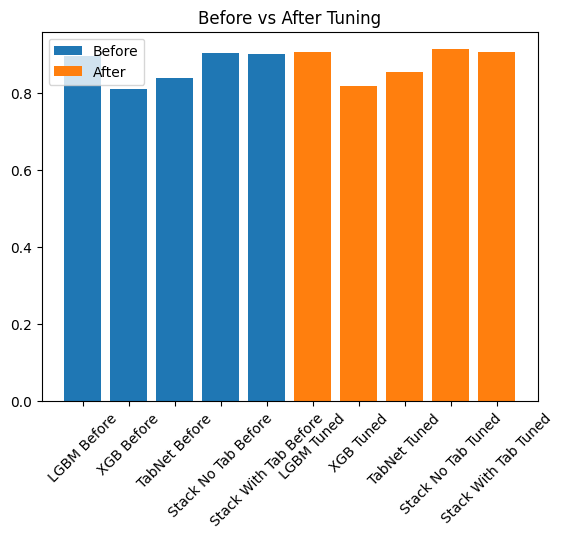

In [ ]:
before = df_results[df_results.index.str.contains("Before")]
after = df_results[df_results.index.str.contains("Tuned")]

plt.figure()
plt.bar(before.index, before["Accuracy"], label="Before")
plt.bar(after.index, after["Accuracy"], label="After")

plt.xticks(rotation=45)
plt.legend()
plt.title("Before vs After Tuning")
plt.show()

In [ ]:
history = best_tabnet.history

print(history.history.keys())

train_loss = history.history['loss']
val_acc = history.history['val_0_accuracy']

dict_keys(['loss', 'lr', 'val_0_accuracy'])


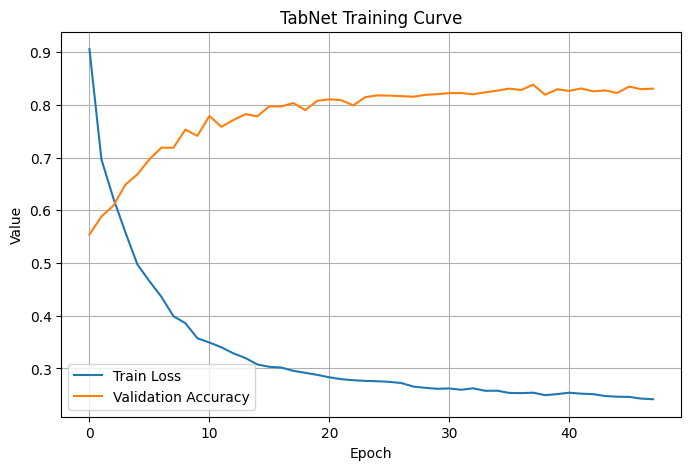

In [ ]:
history = tabnet_final.history

train_loss = history['loss']
val_acc = history['val_0_accuracy']

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_loss, label="Train Loss")
plt.plot(val_acc, label="Validation Accuracy")

plt.title("TabNet Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Value")

plt.legend()
plt.grid()
plt.show()

In [ ]:
runtime_df = pd.DataFrame(runtime_results)

print("\n==============================")
print("RUNTIME RESULTS")
print("==============================")

print(runtime_df)

summary_table = runtime_df.pivot_table(
    index="Model",
    columns="Phase",
    values="Runtime_Seconds",
    aggfunc="sum"
)

print("\n==============================")
print("RUNTIME SUMMARY TABLE")
print("==============================")

print(summary_table)

print("\n==============================")
print("TOTAL RUNTIME PER MODEL")
print("==============================")

print(
    runtime_df
    .groupby("Model")["Runtime_Seconds"]
    .sum()
    .sort_values(ascending=False)
)


RUNTIME RESULTS
                                      Model          Phase  Runtime_Seconds
0   Stacking Without TabNet (Before Tuning)  Full Pipeline          67.3332
1      Stacking With TabNet (Before Tuning)  Full Pipeline        2257.5810
2                  LightGBM (Before Tuning)       Training           6.0434
3                  LightGBM (Before Tuning)     Prediction           0.2396
4                   XGBoost (Before Tuning)       Training           5.5723
5                   XGBoost (Before Tuning)     Prediction           0.0411
6                    TabNet (Before Tuning)       Training         421.6326
7                    TabNet (Before Tuning)     Prediction           0.7485
8    Stacking Without TabNet (After Tuning)  Full Pipeline          82.3174
9       Stacking With TabNet (After Tuning)  Full Pipeline         931.6183
10      Stacking With TabNet (After Tuning)  Full Pipeline        1001.2702
11      Stacking With TabNet (After Tuning)  Full Pipeline        1141.